In [1]:
import os, sys
sys.path.append('../scripts')
import smyle_handles
import dcpp_handles
import smyle_metrics 
import matplotlib.pyplot as plt 
import numpy as np

# dcpp_handles.inventory()

data = dcpp_handles.get(lead='13-60', var='SLP', remove_gm=True) # set remove_gm=True for SLP 
F = data.F # (N_MEMBERS, N_TIME, N_LAT, N_LON)
g = data.G # (N_TIME, N_LAT, N_LON)
s = np.mean(F, axis=0)
YEAR = data.YEAR # (N_TIME)
MONTH = data.MONTH  # (N_TIME) although they are all the ssame 

KeyboardInterrupt: 

In [ ]:
F.shape

In [3]:
def remove_ticks(axs):
    for ax in axs:
        ax.set_xticks([])
        ax.set_yticks([])

def add_colorbars(fig, ims, axs, fraction=0.04, pad=0.2):
    for i, im in enumerate(ims):
        fig.colorbar(im, ax=axs[i], fraction=fraction, pad=pad)

1981
11


Text(0.5, 1.0, '1981 Ensemble Mean')

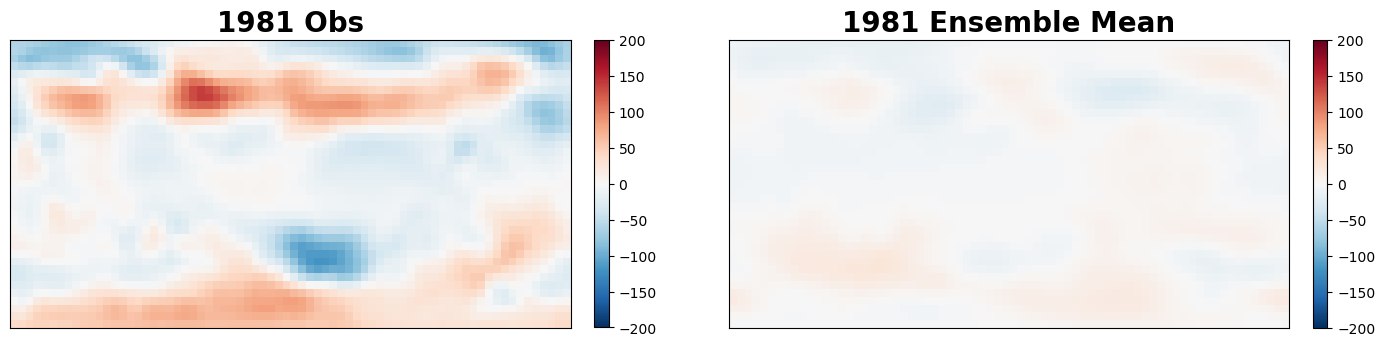

In [4]:
YR_IDX = 20
CLIM_LOWER, CLIM_UPPER = -200, 200
CMAP = 'RdBu_r'
TITLE_SIZE=20

print(YEAR[YR_IDX])
print(MONTH[YR_IDX])

fig, axs = plt.subplots(1, 2, figsize=(17, 7))
im0 = axs[0].imshow(g[YR_IDX,:,:], cmap=CMAP, vmin=CLIM_LOWER, vmax=CLIM_UPPER)
im1 = axs[1].imshow(s[YR_IDX,:,:], cmap=CMAP, vmin=CLIM_LOWER, vmax=CLIM_UPPER)

remove_ticks(axs)
add_colorbars(fig, [im0, im1], axs, fraction=0.024, pad=0.04)

axs[0].set_title(f'{data.YEAR[YR_IDX]} Obs', fontsize=TITLE_SIZE, fontweight=800)
axs[1].set_title(f'{data.YEAR[YR_IDX]} Ensemble Mean', fontsize=TITLE_SIZE, fontweight=800)

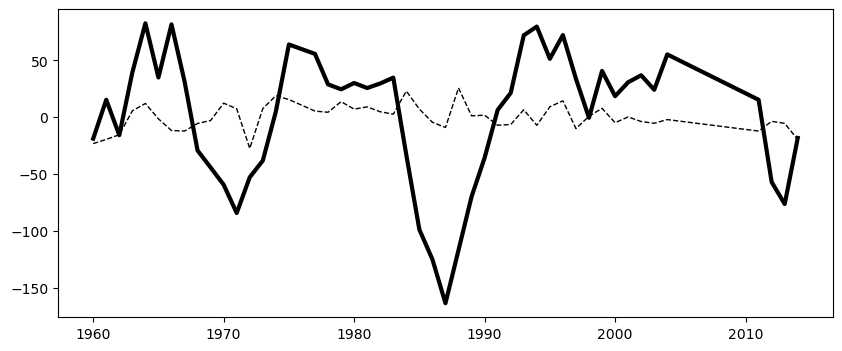

In [5]:
a1, a2 = 30, 40
b1, b2 = 50, 60

fig, axs = plt.subplots(1, 1, figsize=(10, 4))
plt.plot(YEAR, np.mean(g[:, a1:a2, b1:b2], axis=(1, 2)), 'k-', lw=3)
plt.plot(YEAR, np.mean(s[:, a1:a2, b1:b2], axis=(1, 2)), 'k--', lw=1)

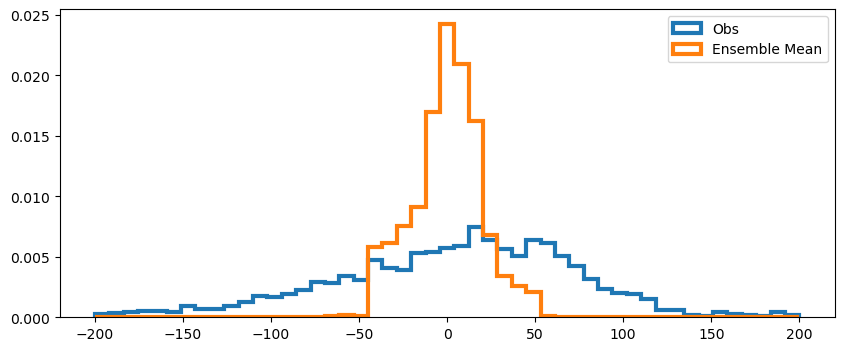

In [8]:
a1, a2 = 30, 50
b1, b2 = 30, 40
BIN_LOWER, BIN_UPPER = -200, 200
NUM_BINS = 50

fig, axs = plt.subplots(1, 1, figsize=(10, 4))
axs.hist(g[:, a1:a2, b1:b2].flatten(), 
         bins=np.linspace(BIN_LOWER, BIN_UPPER, NUM_BINS), 
         histtype='step', alpha=1.0, lw=3, density=True, label='Obs');
axs.hist(s[:, a1:a2, b1:b2].flatten(), 
         bins=np.linspace(BIN_LOWER, BIN_UPPER, NUM_BINS), 
         histtype='step', alpha=1.0, lw=3, density=True, label='Ensemble Mean');
axs.legend()

Text(0, 0.5, 'Ensemble Mean SLP Anomaly')

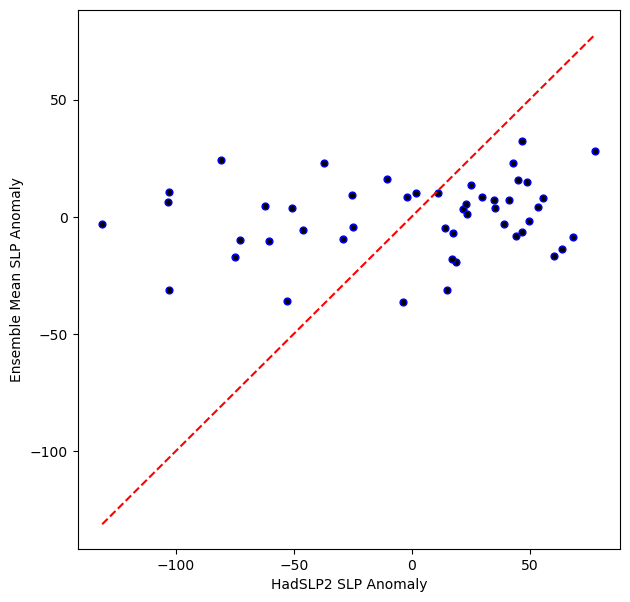

In [9]:
a1, a2 = 30, 50
b1, b2 = 30, 40

g_mean = np.mean(g[:, a1:a2, b1:b2], axis=(1, 2))
s_mean = np.mean(s[:, a1:a2, b1:b2], axis=(1, 2))
x = np.linspace(np.min(g_mean), np.max(g_mean), 25)
fig, axs = plt.subplots(1, 1, figsize=(7, 7))
plt.scatter(g_mean, s_mean, 24, 'k', edgecolor='blue')
plt.plot(x, x, 'r--')
plt.xlabel('HadSLP2 SLP Anomaly')
plt.ylabel('Ensemble Mean SLP Anomaly')

In [10]:
rho_o = smyle_metrics.pearson_coeff(s, g)
rho_m = smyle_metrics.ensemble_SNR_debiased(F)

/tmp/ipykernel_23681/2965608131.py:4: RuntimeWarning: divide by zero encountered in divide
  im2 = axs[2].imshow(rho_o / rho_m, cmap='RdBu_r', vmin=0.0, vmax=2.0)


Text(0.5, 1.0, '$\\rho=\\rho_o/\\rho_m$')

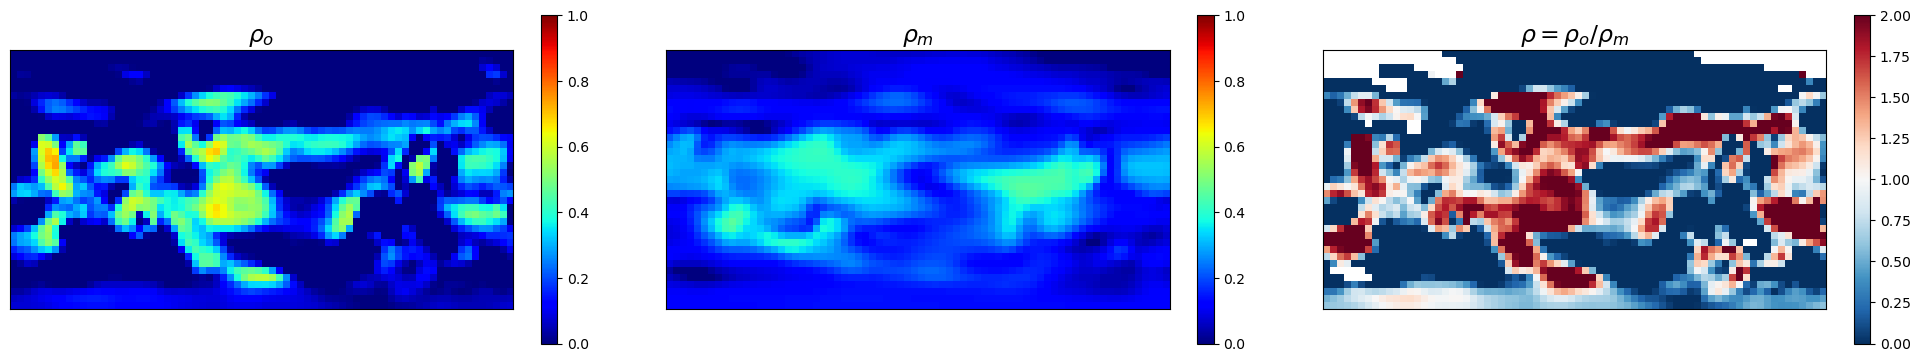

In [11]:
fig, axs = plt.subplots(1, 3, figsize=(24, 12))
im0 = axs[0].imshow(rho_o, cmap='jet', vmin=0, vmax=1)
im1 = axs[1].imshow(rho_m, cmap='jet', vmin=0, vmax=1)
im2 = axs[2].imshow(rho_o / rho_m, cmap='RdBu_r', vmin=0.0, vmax=2.0)
fig.colorbar(im0, ax=axs[0], fraction=0.03)
fig.colorbar(im1, ax=axs[1], fraction=0.03)
fig.colorbar(im2, ax=axs[2], fraction=0.03)
for i in range(3):
    axs[i].set_xticks([])
    axs[i].set_yticks([])

axs[0].set_title('$\\rho_o$', fontsize=17)
axs[1].set_title('$\\rho_m$', fontsize=17)
axs[2].set_title('$\\rho=\\rho_o/\\rho_m$', fontsize=17)

In [77]:
K_NN = 4
MIsG = smyle_metrics.calc_MI_sG_LOOavg(F, g, k=K_NN, use_copula=True)
MIsF = smyle_metrics.calc_MI_sF(F, k=K_NN, use_copula=True)

In [50]:
MIsG_noCopula = smyle_metrics.calc_MI_sG_LOOavg(F, g, k=K_NN, use_copula=False)
MIsF_noCopula = smyle_metrics.calc_MI_sF(F, k=K_NN, use_copula=False)

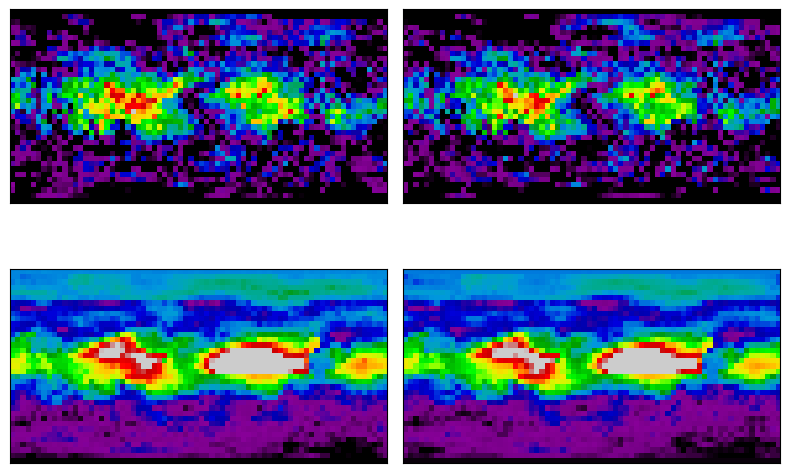

In [51]:
fig, axs = plt.subplots(2, 2, figsize=(8, 6))
axs = axs.flatten() 

CLIM = 0.7
CMAP = 'nipy_spectral'
axs[0].imshow(MIsG, vmin=0, vmax=CLIM, cmap=CMAP)
axs[1].imshow(MIsG_noCopula, vmin=0, vmax=CLIM, cmap=CMAP)
axs[2].imshow(MIsF, vmin=0, vmax=CLIM, cmap=CMAP)
axs[3].imshow(MIsF_noCopula, vmin=0, vmax=CLIM, cmap=CMAP)

remove_ticks(axs)
plt.tight_layout()

In [68]:
k_arr = [1, 3, 5, 7, 9, 11]
MIsG_k = []
for i, k in enumerate(k_arr):
    MIsG_k.append(smyle_metrics.calc_MI_sG_LOOavg(F, g, k=k_arr[i], use_copula=True)) 

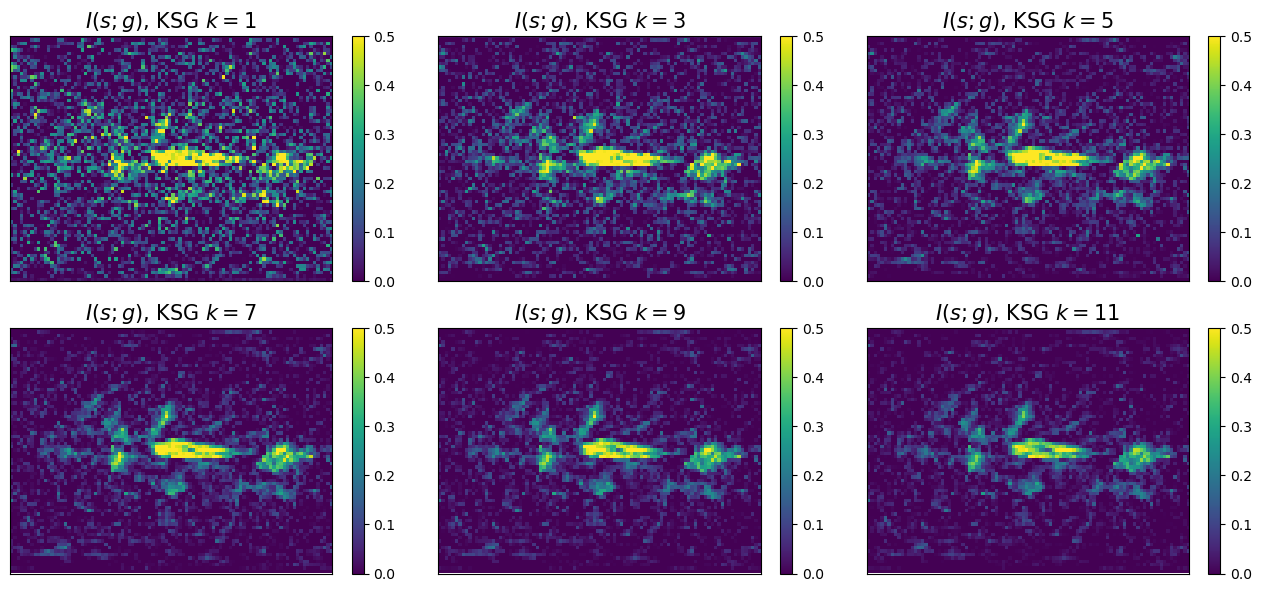

In [69]:
im_arr = [] 

fig, axs = plt.subplots(2, 3, figsize=(13, 6))
axs = axs.flatten()

for i in range(len(k_arr)):
    im_tmp = axs[i].imshow(MIsG_k[i], vmin=0, vmax=0.5)
    im_arr.append(im_tmp)
    axs[i].set_title(f'$I(s;g)$, KSG $k={k_arr[i]}$', fontsize=15)
add_colorbars(fig, im_arr, axs, pad=0.05)
remove_ticks(axs)
plt.tight_layout()

In [78]:
lam_o = smyle_metrics.lam_of(MIsG)
# lam_o[(MIsG<1e-3)] = np.nan
lam_m = smyle_metrics.lam_of(MIsF)
# lam_m[MIsG<1e-3] = np.nan

Text(0.5, 1.0, '$\\lambda=\\lambda_o/\\lambda_m$')

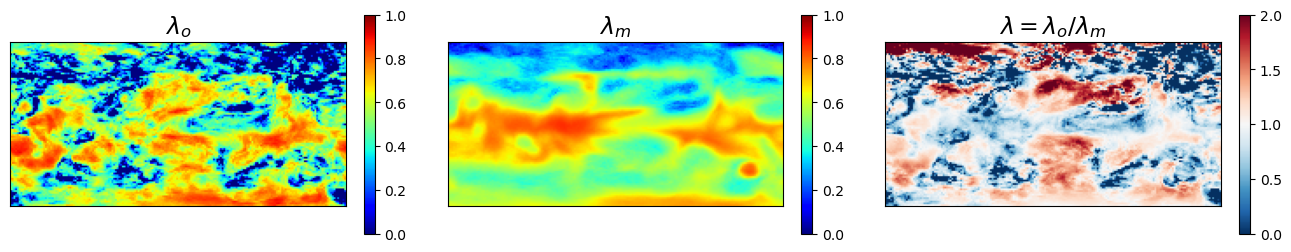

In [79]:
fig, axs = plt.subplots(1, 3, figsize=(16, 5))
im0 = axs[0].imshow(lam_o, cmap='jet', vmin=0, vmax=1)
im1 = axs[1].imshow(lam_m, cmap='jet', vmin=0, vmax=1)
im2 = axs[2].imshow(lam_o / lam_m, cmap='RdBu_r', vmin=0.0, vmax=2.0)
fig.colorbar(im0, ax=axs[0], fraction=0.03)
fig.colorbar(im1, ax=axs[1], fraction=0.03)
fig.colorbar(im2, ax=axs[2], fraction=0.03)
for i in range(3):
    axs[i].set_xticks([])
    axs[i].set_yticks([])

axs[0].set_title('$\\lambda_o$', fontsize=17)
axs[1].set_title('$\\lambda_m$', fontsize=17)
axs[2].set_title('$\\lambda=\\lambda_o/\\lambda_m$', fontsize=17)

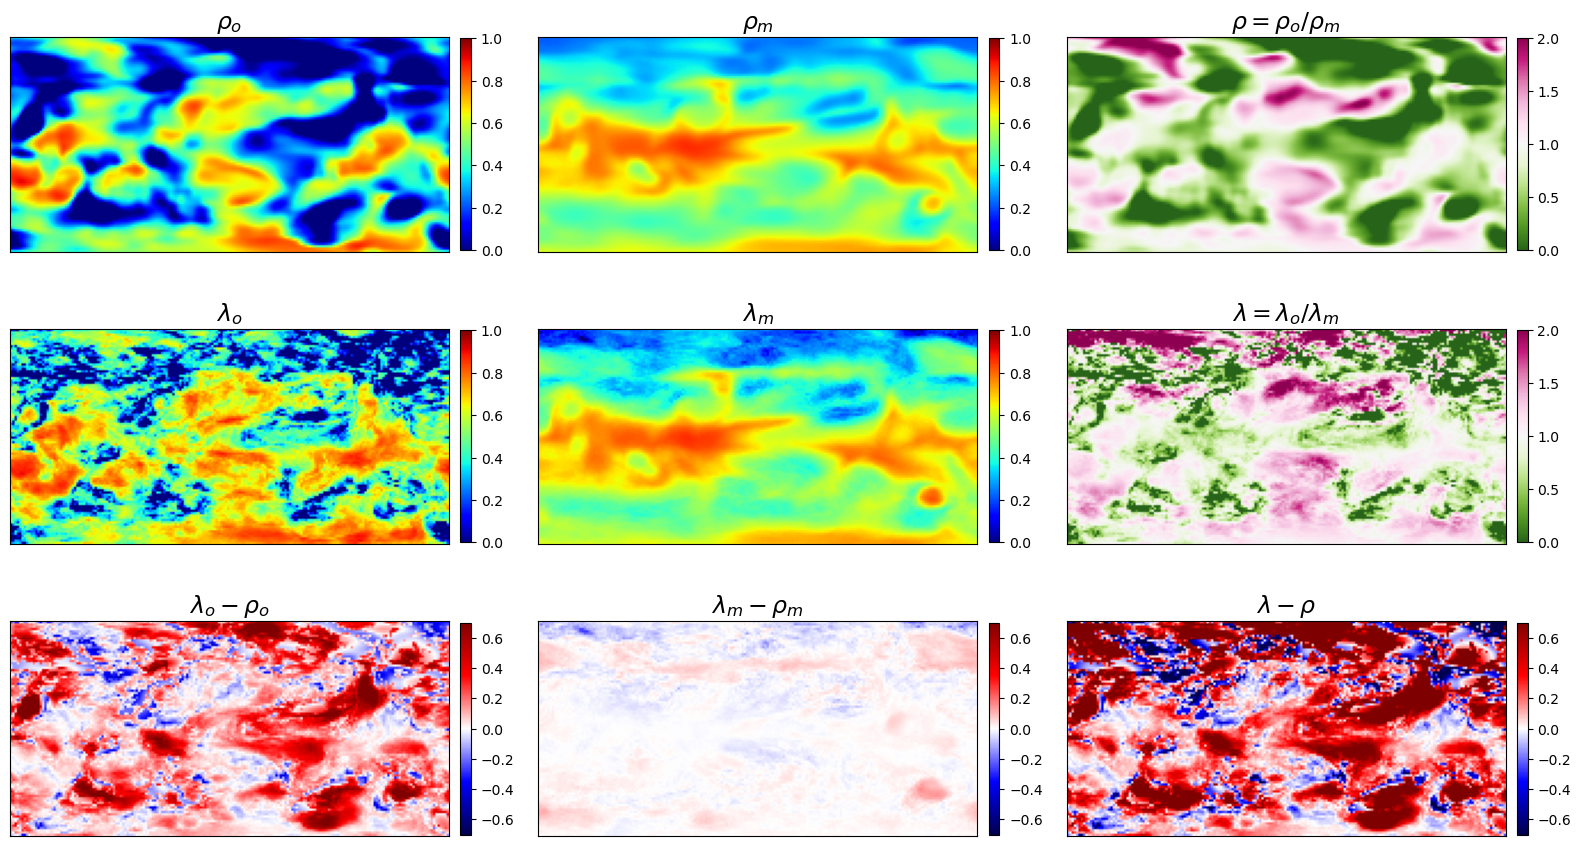

In [95]:
fig, axs = plt.subplots(3, 3, figsize=(16, 9))
axs = axs.flatten()

im0 = axs[0].imshow(rho_o, cmap='jet', vmin=0, vmax=1)
im1 = axs[1].imshow(rho_m, cmap='jet', vmin=0, vmax=1)
im2 = axs[2].imshow(rho_o / rho_m, cmap='PiYG_r', vmin=0.0, vmax=2.0)

im3 = axs[3].imshow(lam_o, cmap='jet', vmin=0, vmax=1)
im4 = axs[4].imshow(lam_m, cmap='jet', vmin=0, vmax=1)
im5 = axs[5].imshow(lam_o / lam_m, cmap='PiYG_r', vmin=0.0, vmax=2.0)

im6 = axs[6].imshow(lam_o - rho_o, vmin=-0.7, vmax=0.7, cmap='seismic')
im7 = axs[7].imshow(lam_m - rho_m, vmin=-0.7, vmax=0.7, cmap='seismic')
im8 = axs[8].imshow(lam_o/lam_m - rho_o/rho_m, vmin=-0.7, vmax=0.7, cmap='seismic')
im_arr = [im0, im1, im2, im3, im4, im5, im6, im7, im8] 

remove_ticks(axs)
add_colorbars(fig, im_arr, axs, fraction=0.023, pad=0.025)

axs[0].set_title('$\\rho_o$', fontsize=17)
axs[1].set_title('$\\rho_m$', fontsize=17)
axs[2].set_title('$\\rho=\\rho_o/\\rho_m$', fontsize=17)

axs[3].set_title('$\\lambda_o$', fontsize=17)
axs[4].set_title('$\\lambda_m$', fontsize=17)
axs[5].set_title('$\\lambda=\\lambda_o/\\lambda_m$', fontsize=17)

axs[6].set_title('$\\lambda_o - \\rho_o$', fontsize=17)
axs[7].set_title('$\\lambda_m - \\rho_m$', fontsize=17)
axs[8].set_title('$\\lambda - \\rho$', fontsize=17)

plt.tight_layout()